## Google Playstore

Uploading datasheet and liberies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
df = pd.read_csv(r"C:\Users\Shiva\OneDrive\Desktop\Python Lib\Practice\EDA\Google playstore\googleplaystore.csv", low_memory= False)
df_user_reviews = pd.read_csv(r"C:\Users\Shiva\OneDrive\Desktop\Python Lib\Practice\EDA\Google playstore\googleplaystore_user_reviews.csv", low_memory = False)
pd.set_option('display.max_column',None)
pd.set_option('display.max_row',None)

# Basic Info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [5]:
df_user_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [6]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [7]:
df_user_reviews.describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,37432.000000,37432.000000
mean,0.182146,0.492704
std,0.351301,0.259949
min,-1.000000,0.000000
25%,0.000000,0.357143
50%,0.150000,0.514286
75%,0.400000,0.650000
max,1.000000,1.000000


In [8]:
df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [9]:
df_user_reviews.dtypes

App                        object
Translated_Review          object
Sentiment                  object
Sentiment_Polarity        float64
Sentiment_Subjectivity    float64
dtype: object

In [10]:
df.shape

(10841, 13)

In [11]:
df_user_reviews.shape

(64295, 5)

In [12]:
df.tail(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [13]:
df_user_reviews.head(5)

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


# Phase 1: Define Your Objectives & Questions

## 1. Category Analysis
- Which category has the highest average rating?
- Which categories have the most apps? Is the market saturated?
- What is the distribution of free vs. paid apps across categories?

## 2. Market & Profitability
- Top 10 most profitable apps (based on price × installs)?
- Are free apps rated higher than paid apps?
- Is there a correlation between app size and rating? Do larger apps get better reviews?
- What is the relationship between number of reviews and app rating?

## 3. User Engagement & Success Factors
- What factors correlate with high installs? (Price? Rating? Size? Category?)
- Does app price affect the number of installs?
- Do apps with more reviews have higher ratings?
- What is the ideal app size for maximum downloads?



## Data cleaning

# ============ 1. CLEAN LAST UPDATED ============

In [14]:

df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')
df = df[df['Last Updated'].notna()]
print(f"After date cleaning: {len(df)} rows")


After date cleaning: 10840 rows


# ============ 2. CLEAN INSTALLS ============

In [15]:
installs_map = {
    '10,000+': 10001, '500,000+': 500001, '5,000,000+': 5000001,
    '50,000,000+': 50000001, '100,000+': 100001, '50,000+': 50001,
    '1,000,000+': 1000001, '10,000,000+': 10000001, '5,000+': 5001,
    '100,000,000+': 100000001, '1,000,000,000+': 1000000001,
    '1,000+': 1001, '500,000,000+': 500000001, '50+': 51,
    '100+': 101, '500+': 501, '10+': 11, '1+': 2, '5+': 6,
    '0+': 1, '0': 0,
    'Free': np.nan
}

df['Installs_Numerics'] = df['Installs'].map(installs_map)
print(f"After installs cleaning: {len(df)} rows")

After installs cleaning: 10840 rows


# ============ 3. CLEAN REVIEWS ============

In [16]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Fill NaN with 0 (assume no reviews = 0)
df['Reviews'] = df['Reviews'].fillna(0)

print(f"After Reviews cleaning: {len(df)} rows")


After Reviews cleaning: 10840 rows


# ============ 4. CLEAN SIZE ============


In [17]:
# - What's the best way to clean the "Size" column (M, k, Varies with device)?
def _size(size):
    if size == 'Varies with device' or pd.isna(size):
        return np.nan
    
    size = str(size).strip()
    
    if size[-1].upper() == 'M':
        return float(size[:-1])
    elif size[-1].upper() == 'K':
        return float(size[:-1]) / 1024
    else:
        try:
            return float(size)
        except:
            return np.nan

df['Size_MB'] = df['Size'].apply(_size)

# Fill missing with median size (instead of dropping)
category_median = df.groupby('Category')['Size_MB'].transform('median')
df['Size_MB'] = df['Size_MB'].fillna(category_median)
# If still NaN, fill with overall median
df['Size_MB'] = df['Size_MB'].fillna(df['Size_MB'].median())
print(f"After Size cleaning: {len(df)} rows")

After Size cleaning: 10840 rows


# ============ 5. CLEAN PRICE ============

In [18]:
# - How do I handle the "+" and commas in the Installs column?
def _price(price):
    if isinstance(price, str):
        price = price.replace('$', '').replace(',', '').replace('Free', '0')
    try:
        return float(price)
    except:
        return np.nan

df['Price_'] = df['Price'].apply(_price)
df = df[df['Price_'].notna()]
print(f"After price cleaning: {len(df)} rows")
df['Price_'].dtypes

After price cleaning: 10840 rows


dtype('float64')

# ============ 6. CLEAN RATING ============

In [19]:
df['Rating'].isna().sum()

np.int64(1474)

# ============ FINAL CHECK ============

In [20]:

print(f"\n✅ Final dataset: {len(df)} rows")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values:")
print(df.isna().sum())



✅ Final dataset: 10840 rows
Columns: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver', 'Installs_Numerics', 'Size_MB', 'Price_']

Missing values:
App                     0
Category                0
Rating               1474
Reviews                 0
Size                    0
Installs                0
Type                    1
Price                   0
Content Rating          0
Genres                  0
Last Updated            0
Current Ver             8
Android Ver             2
Installs_Numerics       0
Size_MB                 0
Price_                  0
dtype: int64


In [21]:
print("\n=== Data Summary ===")
print(f"Total apps: {len(df)}")
print(f"Avg size: {df['Size_MB'].mean():.2f} MB")
print(f"Avg price: ${df['Price_'].mean():.2f}")
print(f"Avg installs: {df['Installs_Numerics'].mean():,.0f}")
print(f"Avg reviews: {df['Reviews'].mean():,.0f}")
print(f"\nDate range: {df['Last Updated'].min()} to {df['Last Updated'].max()}")


=== Data Summary ===
Total apps: 10840
Avg size: 20.32 MB
Avg price: $1.03
Avg installs: 15,464,340
Avg reviews: 444,153

Date range: 2010-05-21 00:00:00 to 2018-08-08 00:00:00


In [22]:
# - How should I handle missing values in the Rating column?
df = df.dropna(subset=['Rating'])
print(f"After dropping missing ratings: {len(df)} rows")

After dropping missing ratings: 9366 rows


In [23]:
df.shape

(9366, 16)

## . User Engagement & Success Factors
- Does app price affect the number of installs?
- Do apps with more reviews have higher ratings?
- What is the ideal app size for maximum downloads?

Text(0.5, 1.0, 'Correlation for high Installation')

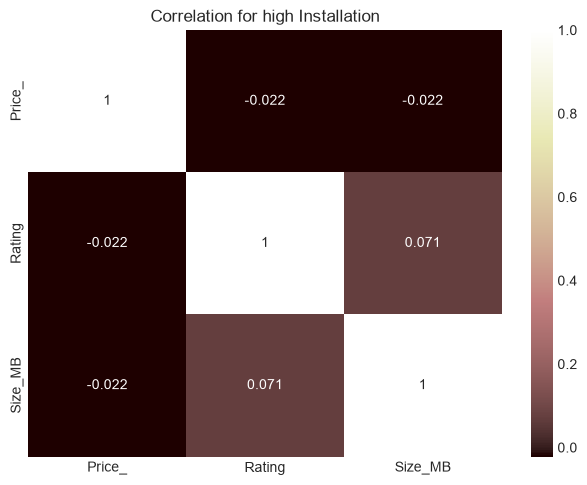

In [24]:
# - What factors correlate with high installs? (Price? Rating? Size? )
corr = df[['Price_','Rating','Size_MB']].corr()
sns.heatmap(corr,annot= True,cmap = 'pink')
plt.tight_layout()
plt.title('Correlation for high Installation')

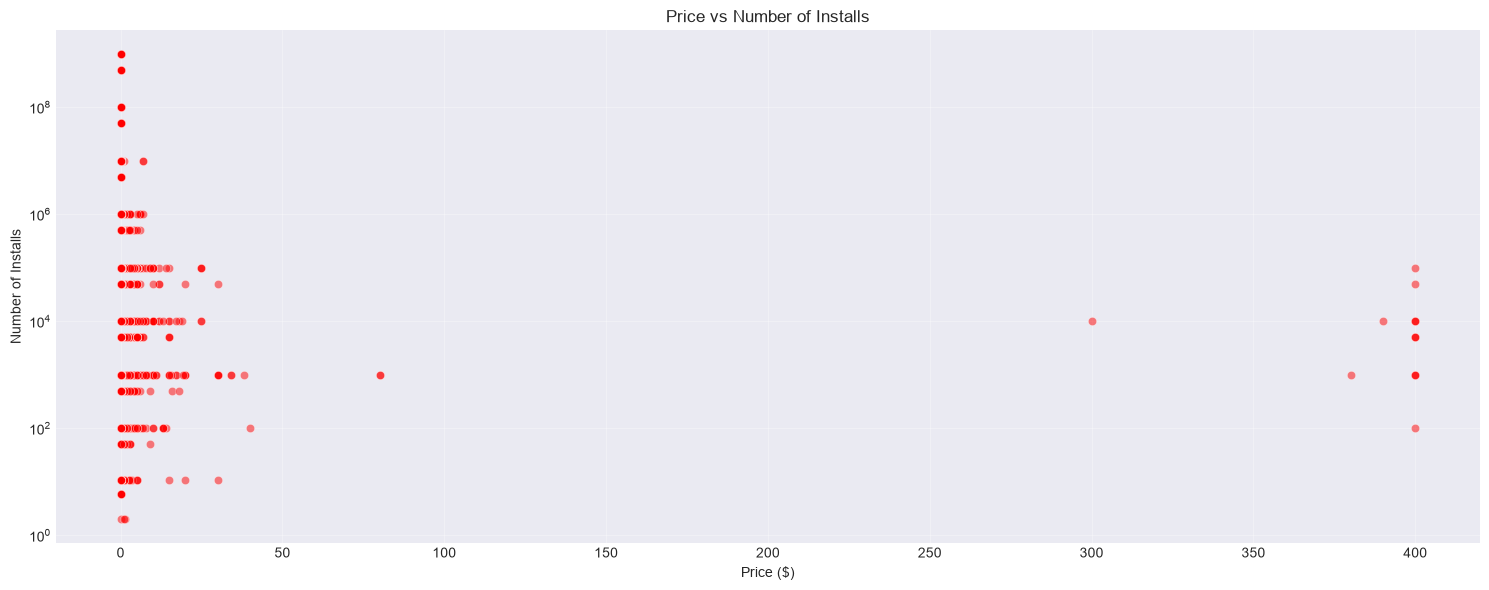

Correlation between Price and Installs: -0.012


In [25]:
# - Does app price affect the number of installs?
plt.figure(figsize=(15,6))
sns.scatterplot(x='Price_', y='Installs_Numerics', data=df,alpha= 0.5,color='red')

# Force y-axis to show actual numbers
plt.yscale('log')  # Log scale for better visualization

plt.xlabel('Price ($)')
plt.ylabel('Number of Installs')
plt.title('Price vs Number of Installs')

# Add grid for better readability
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# Print correlation
correlation = df['Price_'].corr(df['Installs_Numerics'])
print(f"Correlation between Price and Installs: {correlation:.3f}")

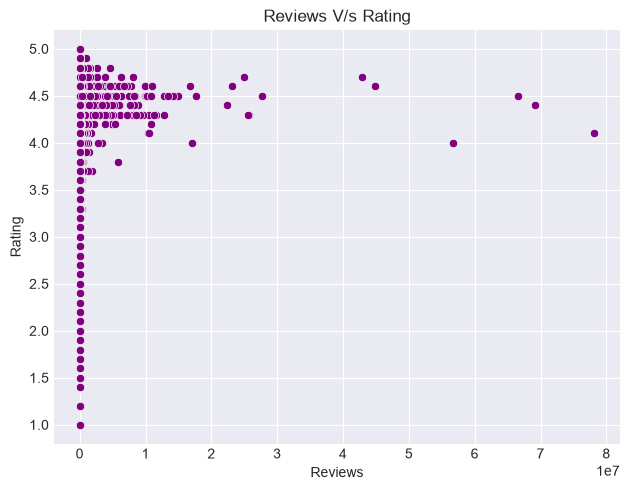

In [26]:
# - Do apps with more reviews have higher ratings?
sns.scatterplot(x = 'Reviews' , y = 'Rating' , data = df,color = 'Purple')
plt.tight_layout()
plt.title("Reviews V/s Rating")
plt.grid(True)

## . Market & Profitability
- Top 10 most profitable apps (based on price × installs)?
- Are free apps rated higher than paid apps?
- Is there a correlation between app size and rating? Do larger apps get better reviews?
- What is the relationship between number of reviews and app rating?

In [27]:
# - Top 10 most profitable apps (based on price × installs)?
df['Revenue_Estimated'] = df["Price_"]*df['Installs_Numerics']
Top = df.nlargest(10,'Revenue_Estimated')
Top[['App','Price_','Size','Installs']]

,App,Price_,Size,Installs
2241,Minecraft,6.99,Varies with device,"10,000,000+"
4347,Minecraft,6.99,Varies with device,"10,000,000+"
5351,I am rich,399.99,1.8M,"100,000+"
5356,I Am Rich Premium,399.99,4.7M,"50,000+"
4034,Hitman Sniper,0.99,29M,"10,000,000+"
7417,Grand Theft Auto: San Andreas,6.99,26M,"1,000,000+"
2883,Facetune - For Free,5.99,48M,"1,000,000+"
2912,Facetune - For Free,5.99,48M,"1,000,000+"
2950,Facetune - For Free,5.99,48M,"1,000,000+"
5578,Sleep as Android Unlock,5.99,872k,"1,000,000+"


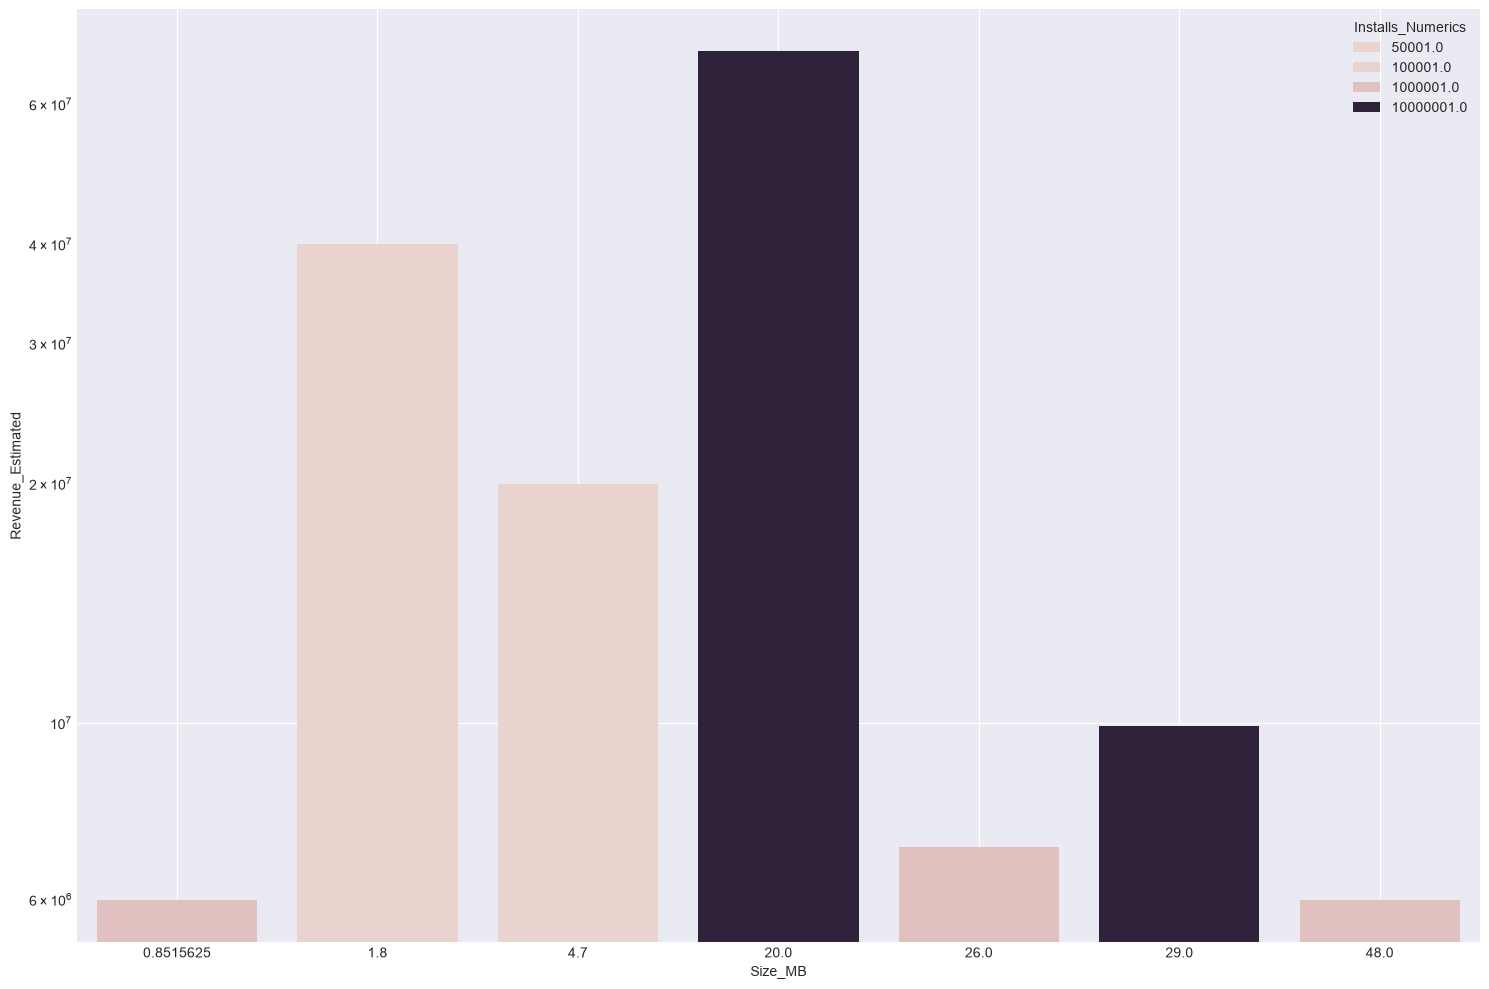

In [28]:
plt.figure(figsize=(15,10))
sns.barplot(x = 'Size_MB' , y = 'Revenue_Estimated' , hue= 'Installs_Numerics', data= Top)
plt.yscale('log')
plt.grid(True)
plt.tight_layout()


C:\Users\Shiva\AppData\Local\Temp\ipykernel_22604\3005781225.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Rating', data=df, palette='Set2')


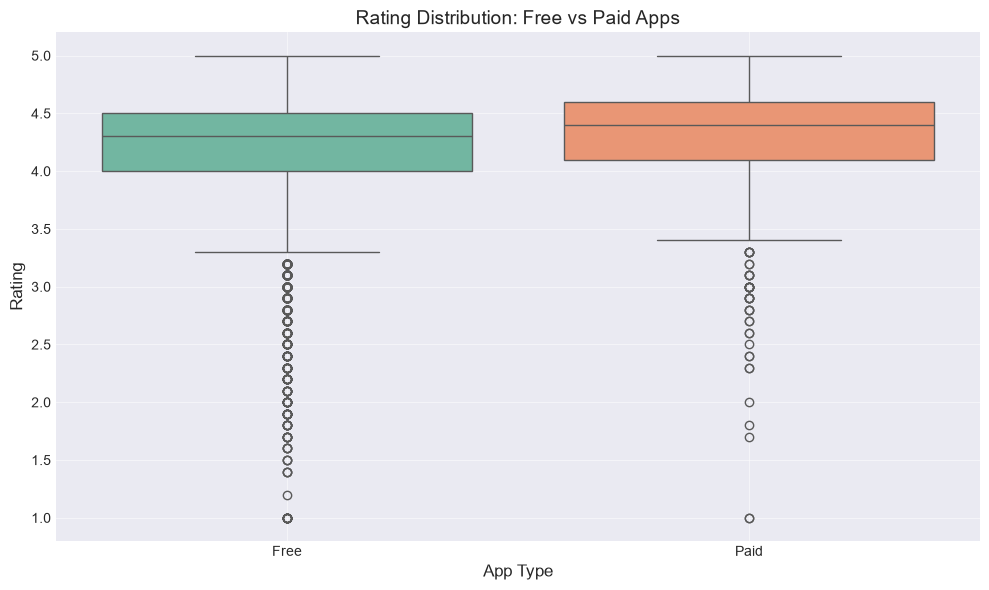

In [29]:
# - Are free apps rated higher than paid apps?
plt.figure(figsize=(10, 6))
sns.boxplot(x='Type', y='Rating', data=df, palette='Set2')

plt.title('Rating Distribution: Free vs Paid Apps', fontsize=14)
plt.xlabel('App Type', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

Correlation between Reviews and Rating: 0.071


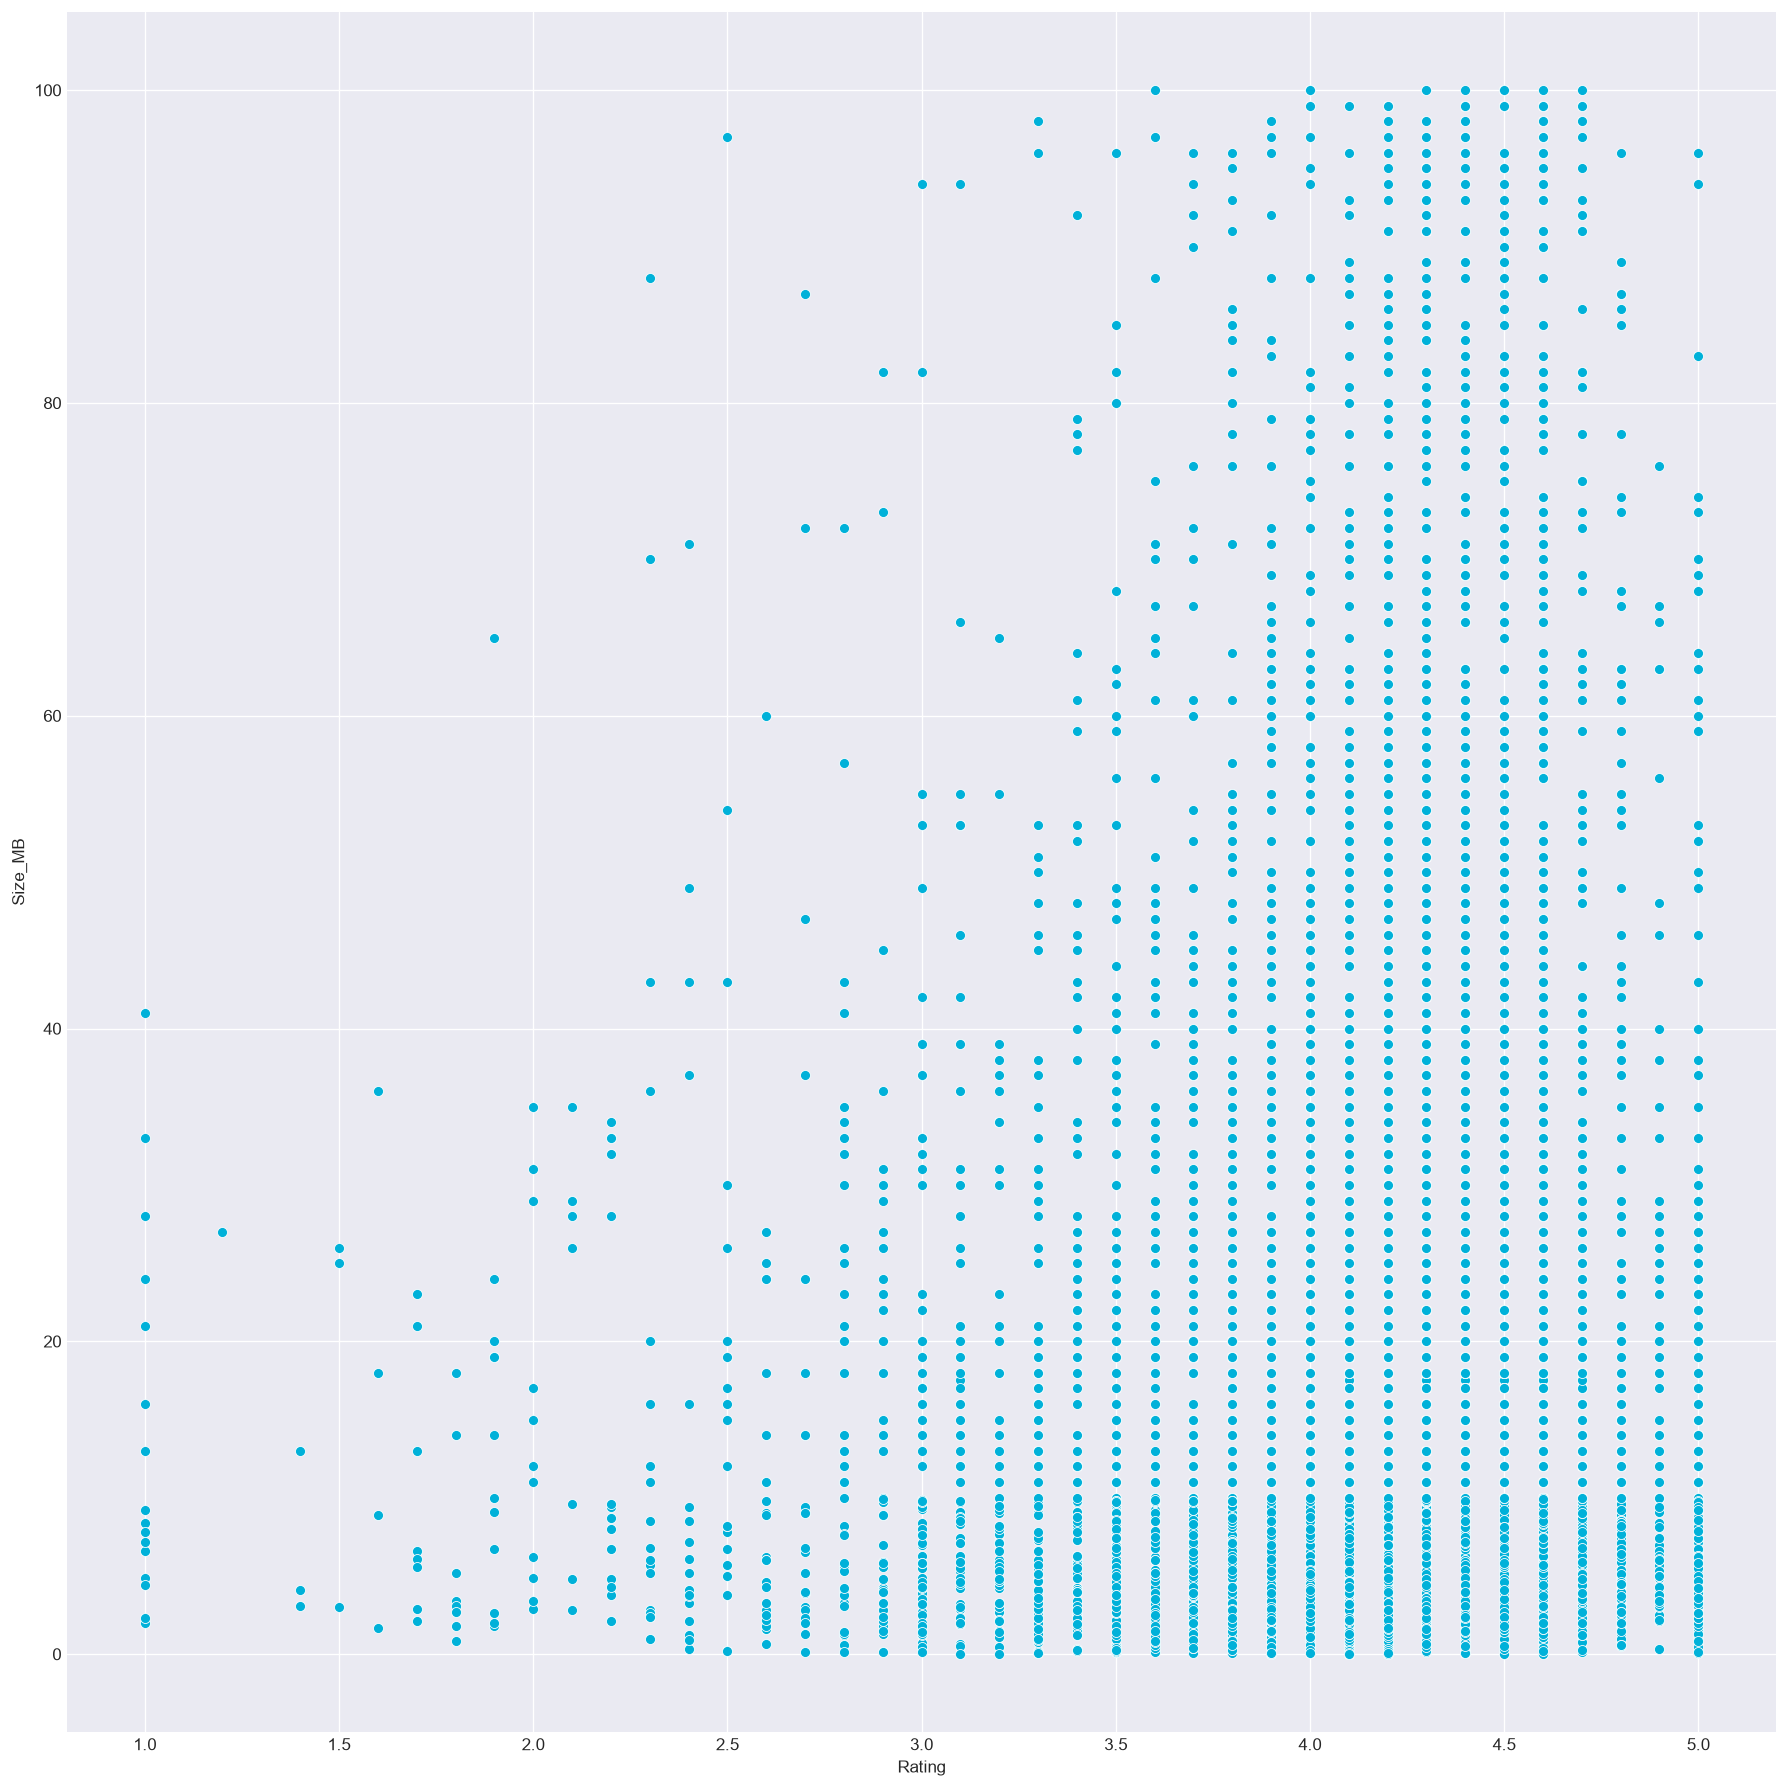

In [30]:
#- Is there a correlation between app size and rating? Do larger apps get better reviews?
plt.figure(figsize=(15,15),dpi=120)
sns.scatterplot(x = 'Rating' , y= 'Size_MB', data = df,color= "#00B1D9")
plt.tight_layout()
# Calculate correlation
correlation = df['Size_MB'].corr(df['Rating'])
print(f"Correlation between Reviews and Rating: {correlation:.3f}")

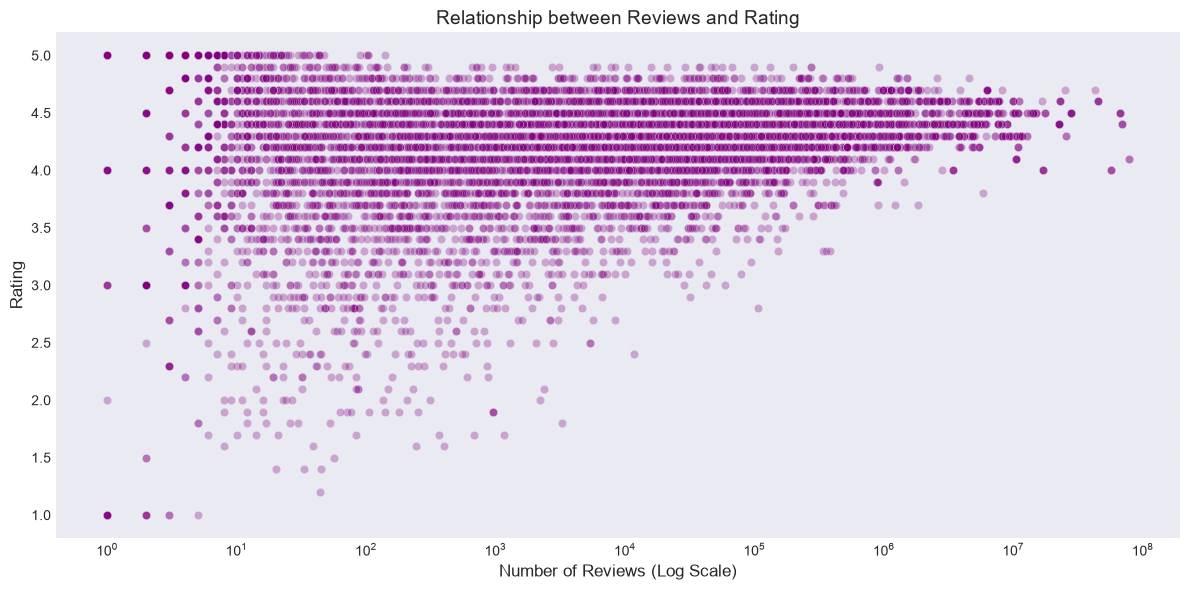

Correlation between Reviews and Rating: 0.068


In [31]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Reviews', y='Rating', data=df, alpha=0.3, color='purple')

plt.xscale('log')  # Log scale because reviews vary hugely
plt.xlabel('Number of Reviews (Log Scale)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.title('Relationship between Reviews and Rating', fontsize=14)
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df['Reviews'].corr(df['Rating'])
print(f"Correlation between Reviews and Rating: {correlation:.3f}")

## . Category Analysis
- Which category has the highest average rating?
- Which categories have the most apps? Is the market saturated?
- What is the distribution of free vs. paid apps across categories?

C:\Users\Shiva\AppData\Local\Temp\ipykernel_22604\2853138871.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Cat.values,y=Cat.index,palette='rainbow')


<Axes: ylabel='Category'>

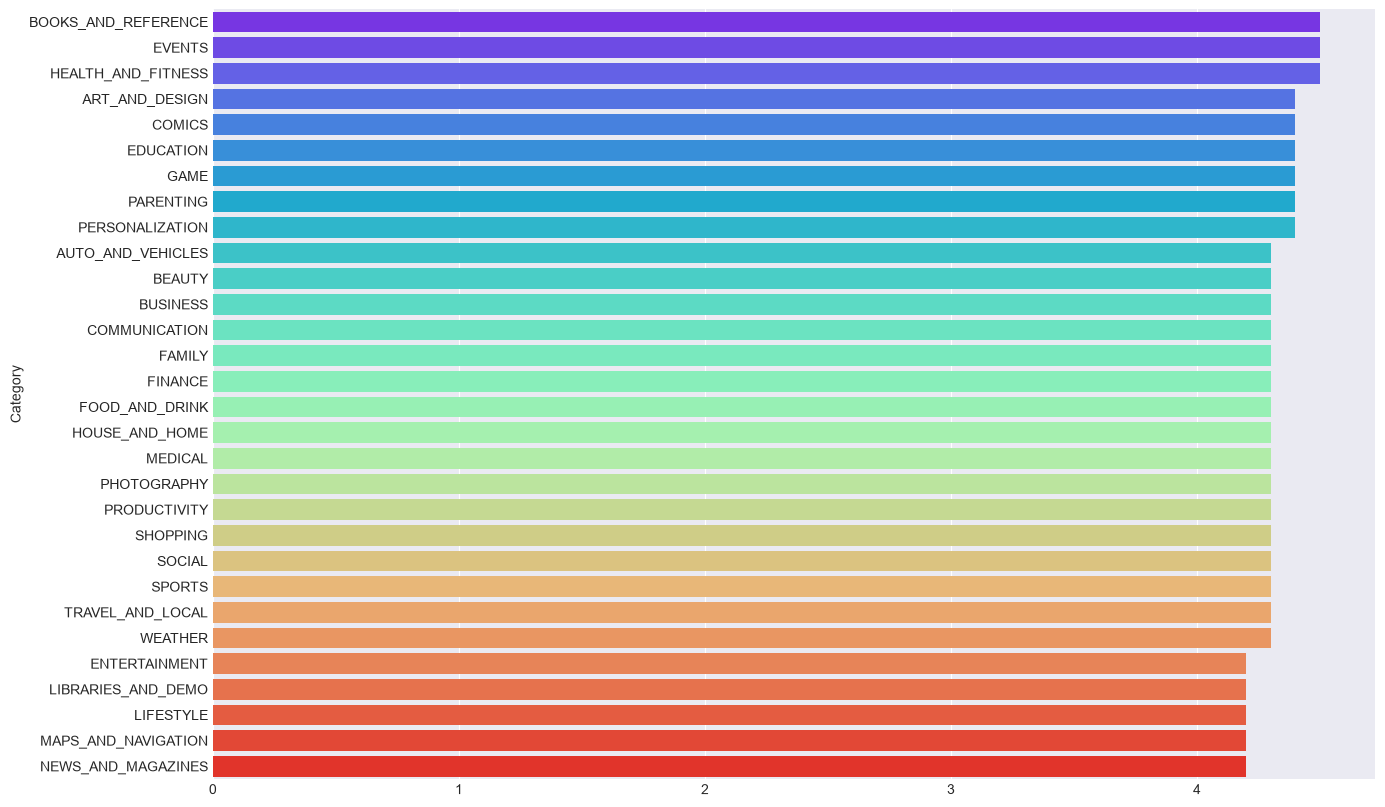

In [32]:
#- Which category has the highest average rating?
plt.figure(figsize= (15,10))
Cat = df.groupby('Category')['Rating'].median().nlargest(30)
sns.barplot(x=Cat.values,y=Cat.index,palette='rainbow')

C:\Users\Shiva\AppData\Local\Temp\ipykernel_22604\58688627.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_app.values, y=most_app.index, palette='mako')


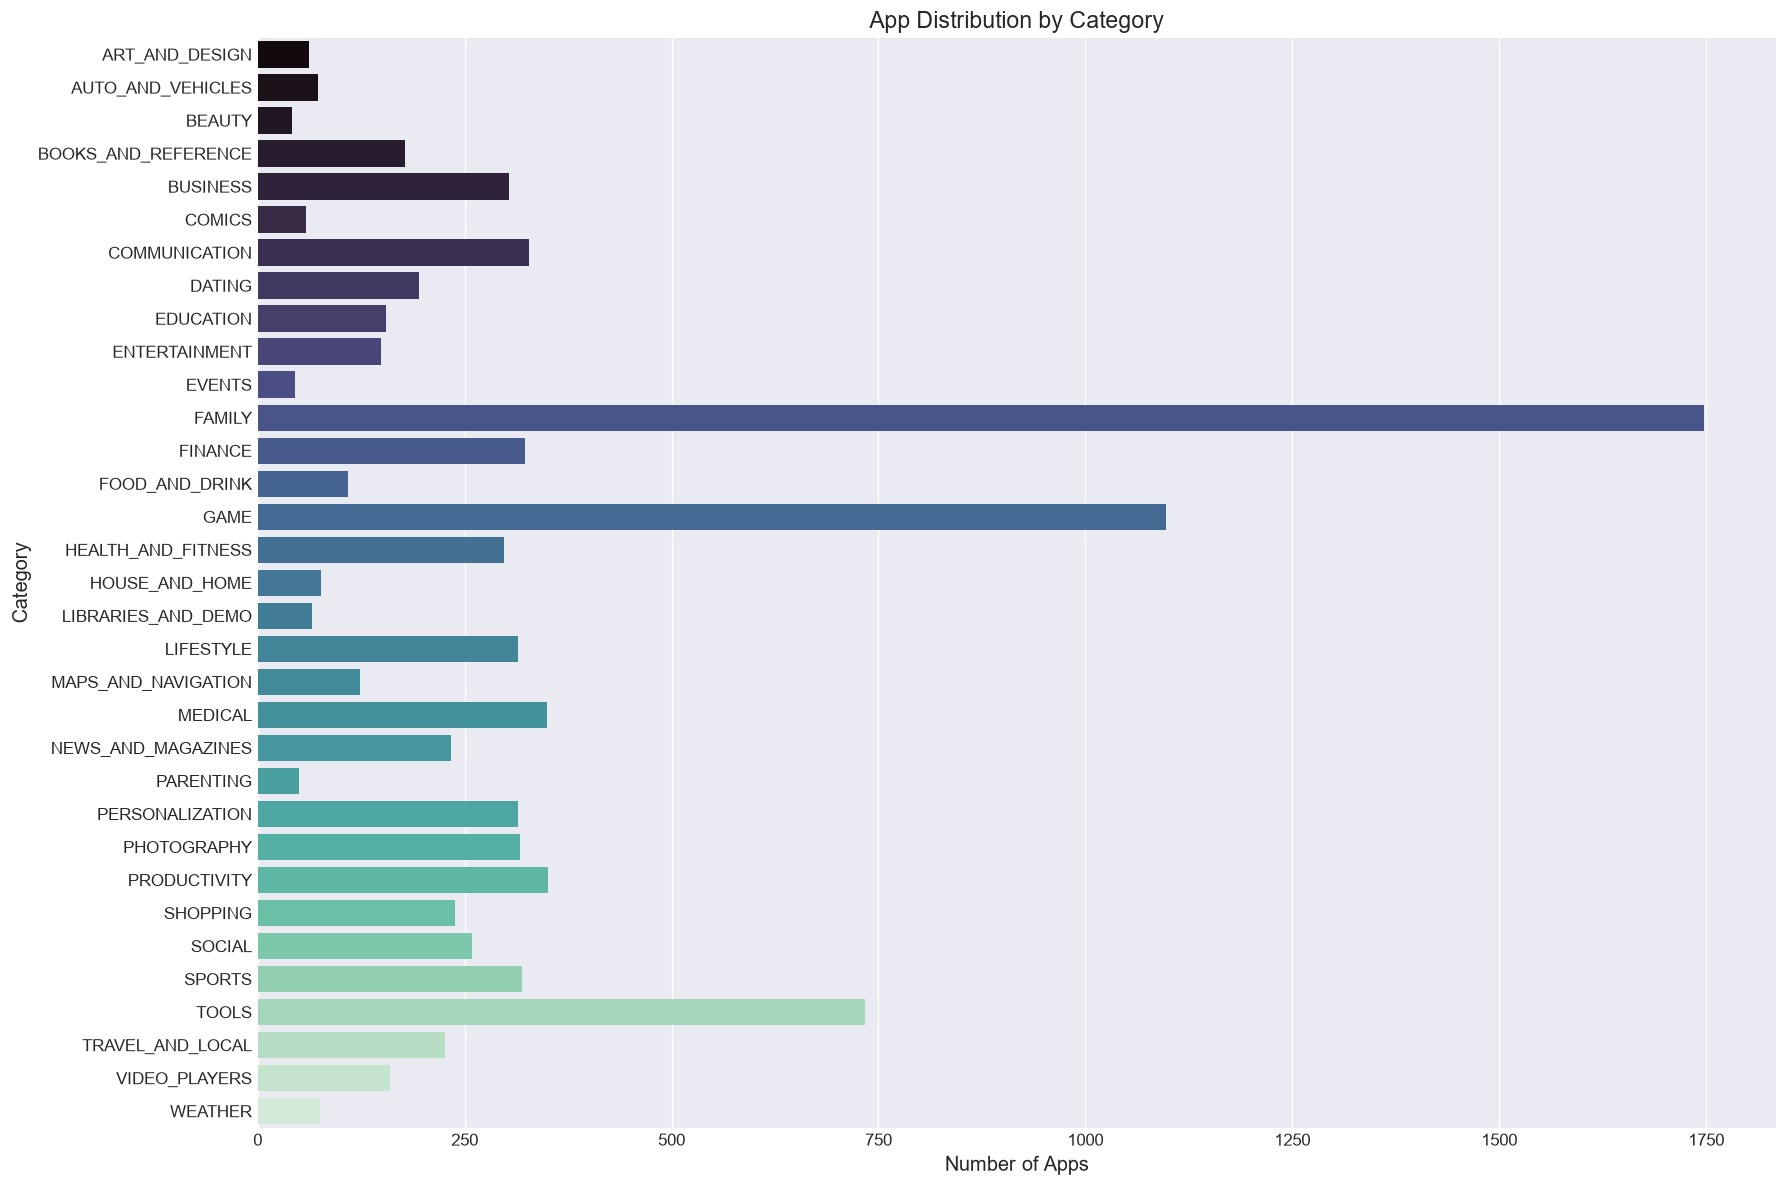

In [33]:
# - Which categories have the most apps? Is the market saturated?
plt.figure(figsize=(15,10), dpi=120)
most_app = df.groupby('Category')['App'].count()
sns.barplot(x=most_app.values, y=most_app.index, palette='mako')
plt.xlabel('Number of Apps', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.title('App Distribution by Category', fontsize=14)
plt.tight_layout()
plt.show()

In [34]:
#- What is the distribution of free vs. paid apps across categories?
pd.crosstab(df['Category'], df['Type'])

Type,Free,Paid
Category,,
ART_AND_DESIGN,59,3
AUTO_AND_VEHICLES,72,1
BEAUTY,42,0
BOOKS_AND_REFERENCE,170,8
BUSINESS,292,11
COMICS,58,0
COMMUNICATION,306,22
DATING,191,4
EDUCATION,151,4


C:\Users\Shiva\AppData\Local\Temp\ipykernel_22604\21240622.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')


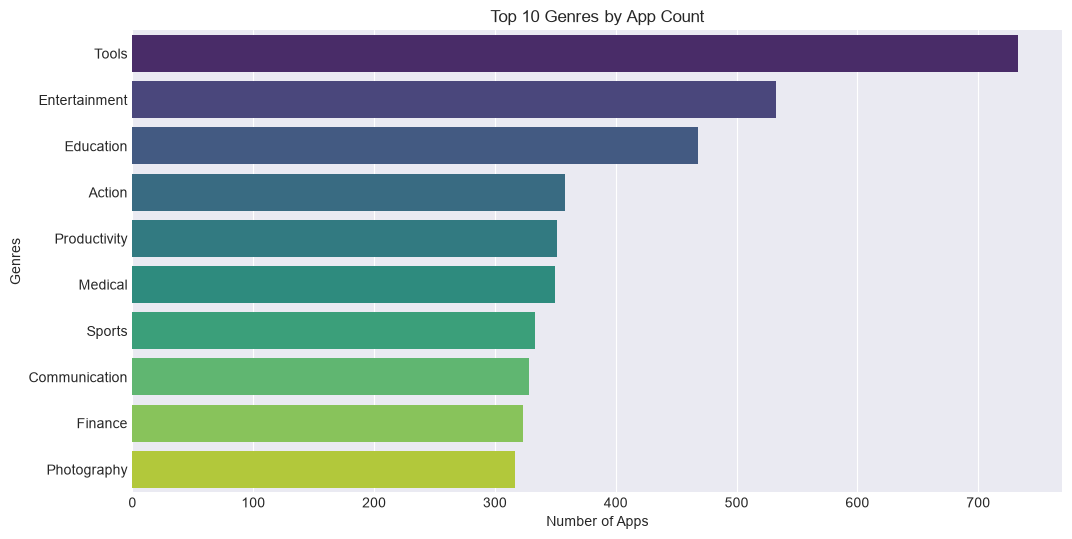

In [35]:
# Genres column!
genre_counts = df['Genres'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Top 10 Genres by App Count')
plt.xlabel('Number of Apps')
plt.show()

In [36]:
print("\n" + "="*60)
print("RECOMMENDATIONS FOR APP DEVELOPERS")
print("="*60)

print("""
1. 📱 CATEGORY CHOICE:
   • Avoid saturated categories (Family, Games, Tools)
   • Consider high-rated niche categories (Events, Education)

2. 💰 PRICING STRATEGY:
   • Free apps get more installs
   • Paid apps have slightly higher ratings
   • Consider freemium model

3. 📐 APP SIZE:
   • Size doesn't significantly affect ratings
   • Optimal size for maximum installs: 10-20MB

4. 📝 USER ENGAGEMENT:
   • More reviews = slightly higher ratings
   • Encourage user reviews

5. ⏰ MAINTENANCE:
   • Regular updates correlate with higher ratings
   • Don't abandon apps for >1 year

6. 🎯 TARGET:
   • Focus on high-rated categories
   • Target appropriate content rating (Everyone, Teen)
""")


RECOMMENDATIONS FOR APP DEVELOPERS

1. 📱 CATEGORY CHOICE:
   • Avoid saturated categories (Family, Games, Tools)
   • Consider high-rated niche categories (Events, Education)

2. 💰 PRICING STRATEGY:
   • Free apps get more installs
   • Paid apps have slightly higher ratings
   • Consider freemium model

3. 📐 APP SIZE:
   • Size doesn't significantly affect ratings
   • Optimal size for maximum installs: 10-20MB

4. 📝 USER ENGAGEMENT:
   • More reviews = slightly higher ratings
   • Encourage user reviews

5. ⏰ MAINTENANCE:
   • Regular updates correlate with higher ratings
   • Don't abandon apps for >1 year

6. 🎯 TARGET:
   • Focus on high-rated categories
   • Target appropriate content rating (Everyone, Teen)



In [37]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_Numerics,Size_MB,Price_,Revenue_Estimated
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,10001.0,19.0,0.0,0.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,500001.0,14.0,0.0,0.0


<Figure size 2600x2600 with 0 Axes>

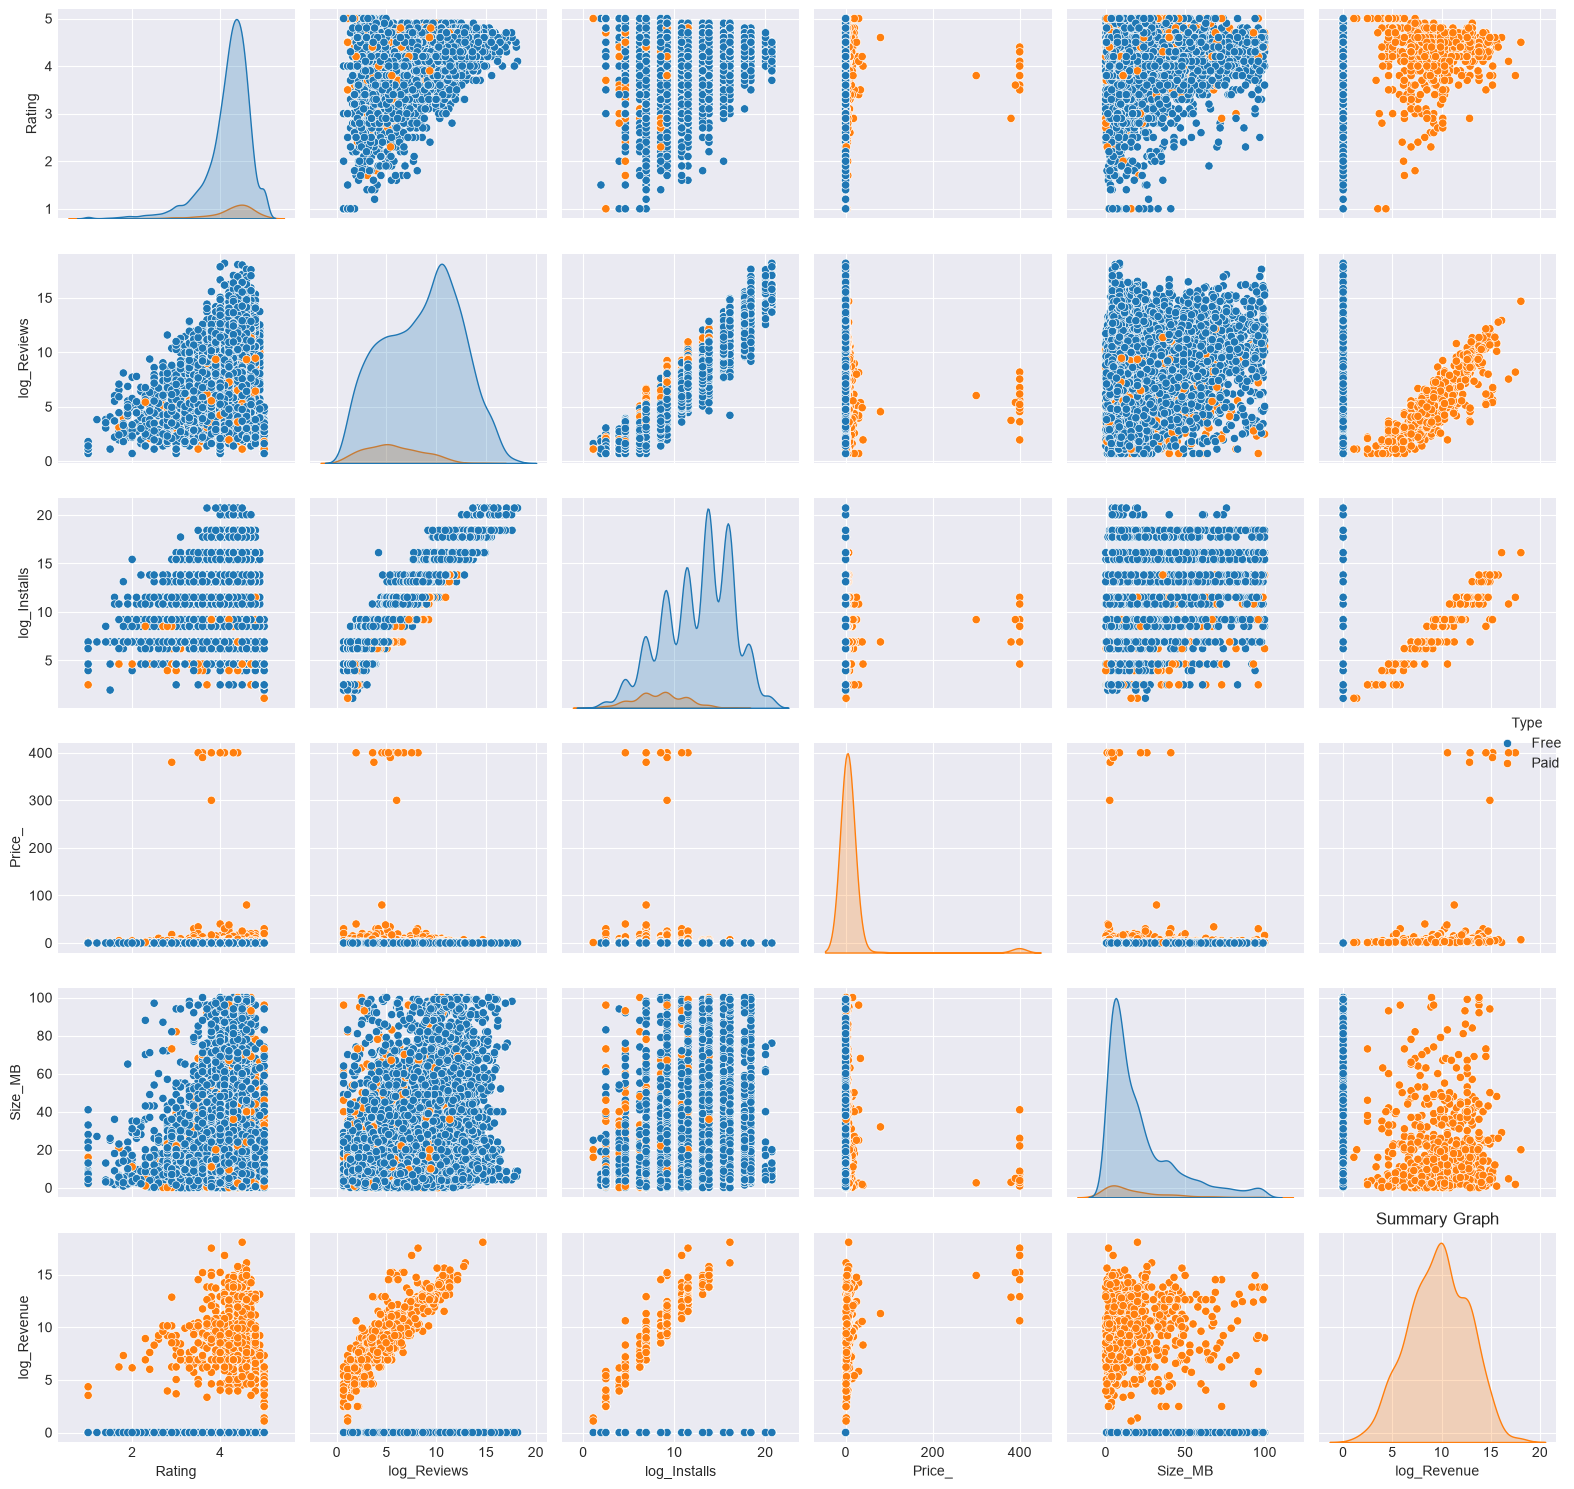

In [38]:
plt.figure(figsize=(20,20),dpi=130)
# 1. Create log-transformed columns (avoid log(0) errors)
df['log_Reviews'] = np.log1p(df['Reviews'])  # log(1+x) handles zeros
df['log_Installs'] = np.log1p(df['Installs_Numerics'])
df['log_Revenue'] = np.log1p(df['Revenue_Estimated'])
sns.pairplot(df[['Category','Rating','log_Reviews','log_Installs','Price_','Size_MB','Genres','log_Revenue','Type']],hue='Type')
plt.title('Summary Graph')
plt.tight_layout()

In [39]:
# Save your cleaned data
df.to_csv('cleaned_google_play_apps.csv', index=False)

# Create a summary report
summary = {
    'Total Apps': len(df),
    'Categories': df['Category'].nunique(),
    'Free %': f"{(df['Type']=='Free').sum()/len(df)*100:.1f}%",
    'Paid %': f"{(df['Type']=='Paid').sum()/len(df)*100:.1f}%",
    'Avg Rating': f"{df['Rating'].mean():.2f}",
    'Avg Installs': f"{df['Installs_Numerics'].mean():,.0f}",
    'Top Category': df['Category'].value_counts().index[0],
    'Best Rated': df.groupby('Category')['Rating'].mean().idxmax()
}

print("\n📊 PROJECT SUMMARY:")
for key, value in summary.items():
    print(f"  {key}: {value}")


📊 PROJECT SUMMARY:
  Total Apps: 9366
  Categories: 33
  Free %: 93.1%
  Paid %: 6.9%
  Avg Rating: 4.19
  Avg Installs: 17,897,445
  Top Category: FAMILY
  Best Rated: EVENTS
